In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
from specparam import SpectralModel
from specparam import Bands
import neurodsp as ndp
from scipy.stats import zscore

# NeuroDSP scipy and FOOOF modules
from neurodsp import spectral




#  modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from signal_utils import * 
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS

### Set up

In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'

In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

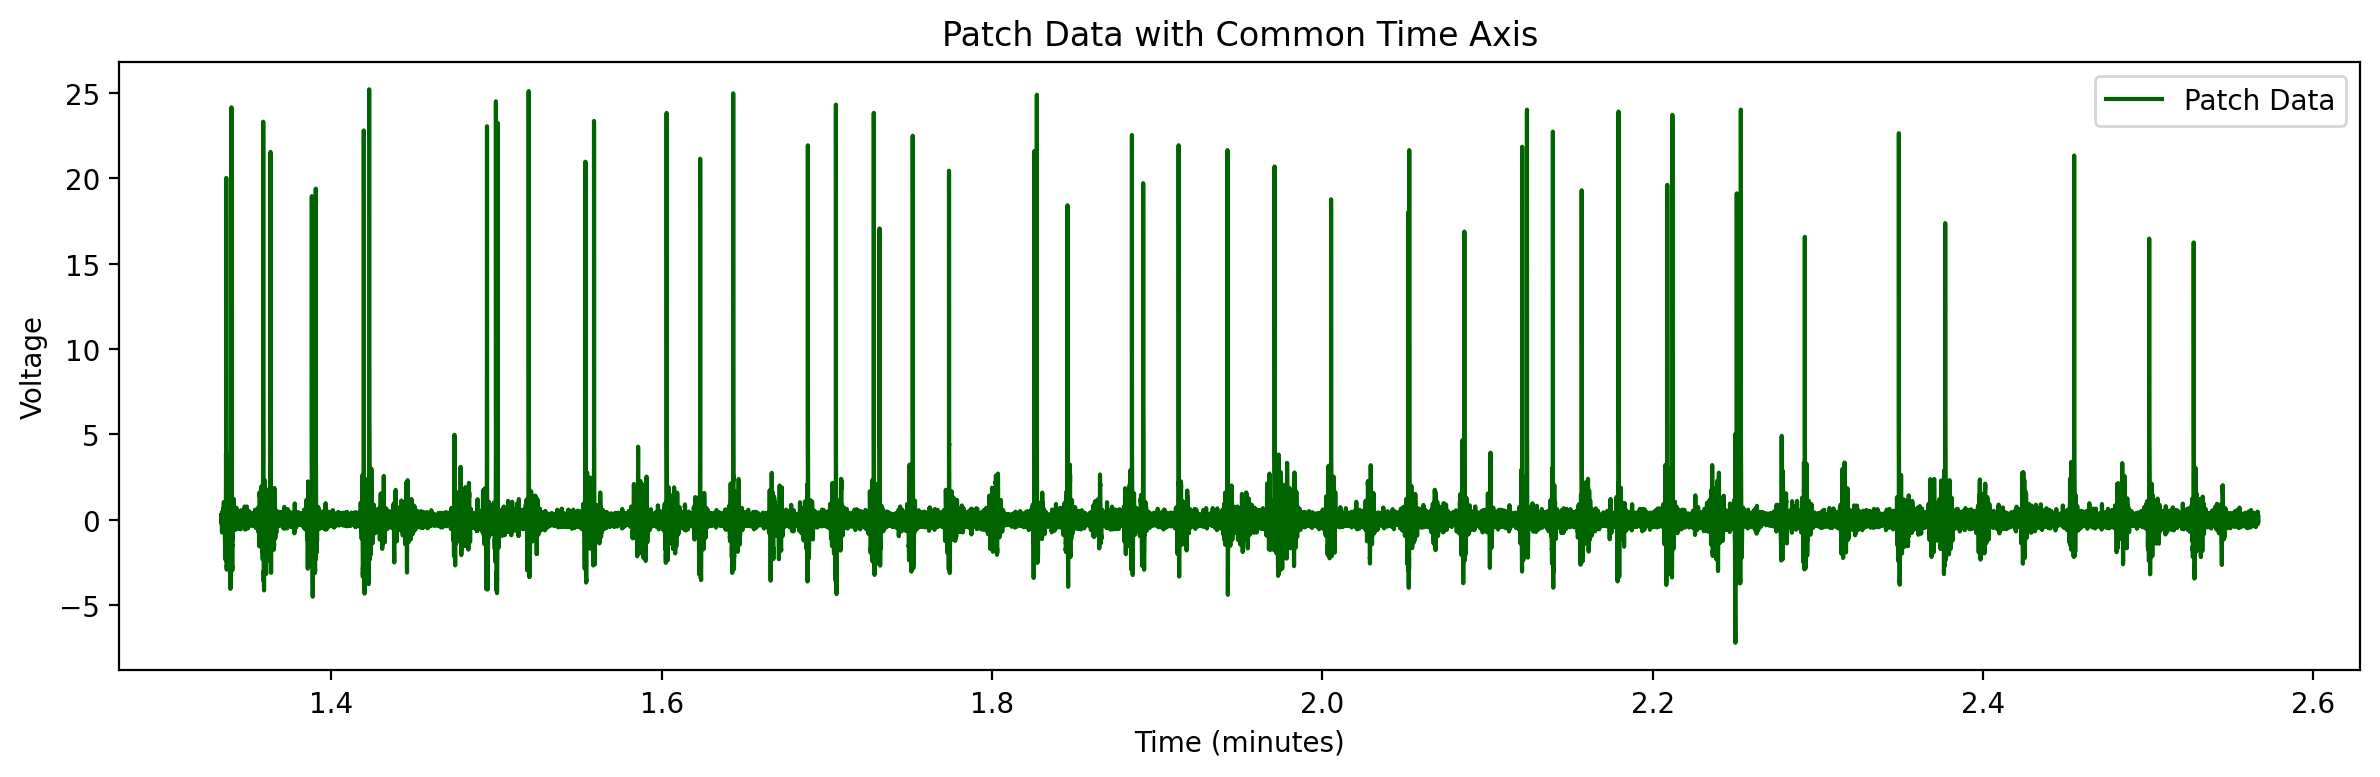

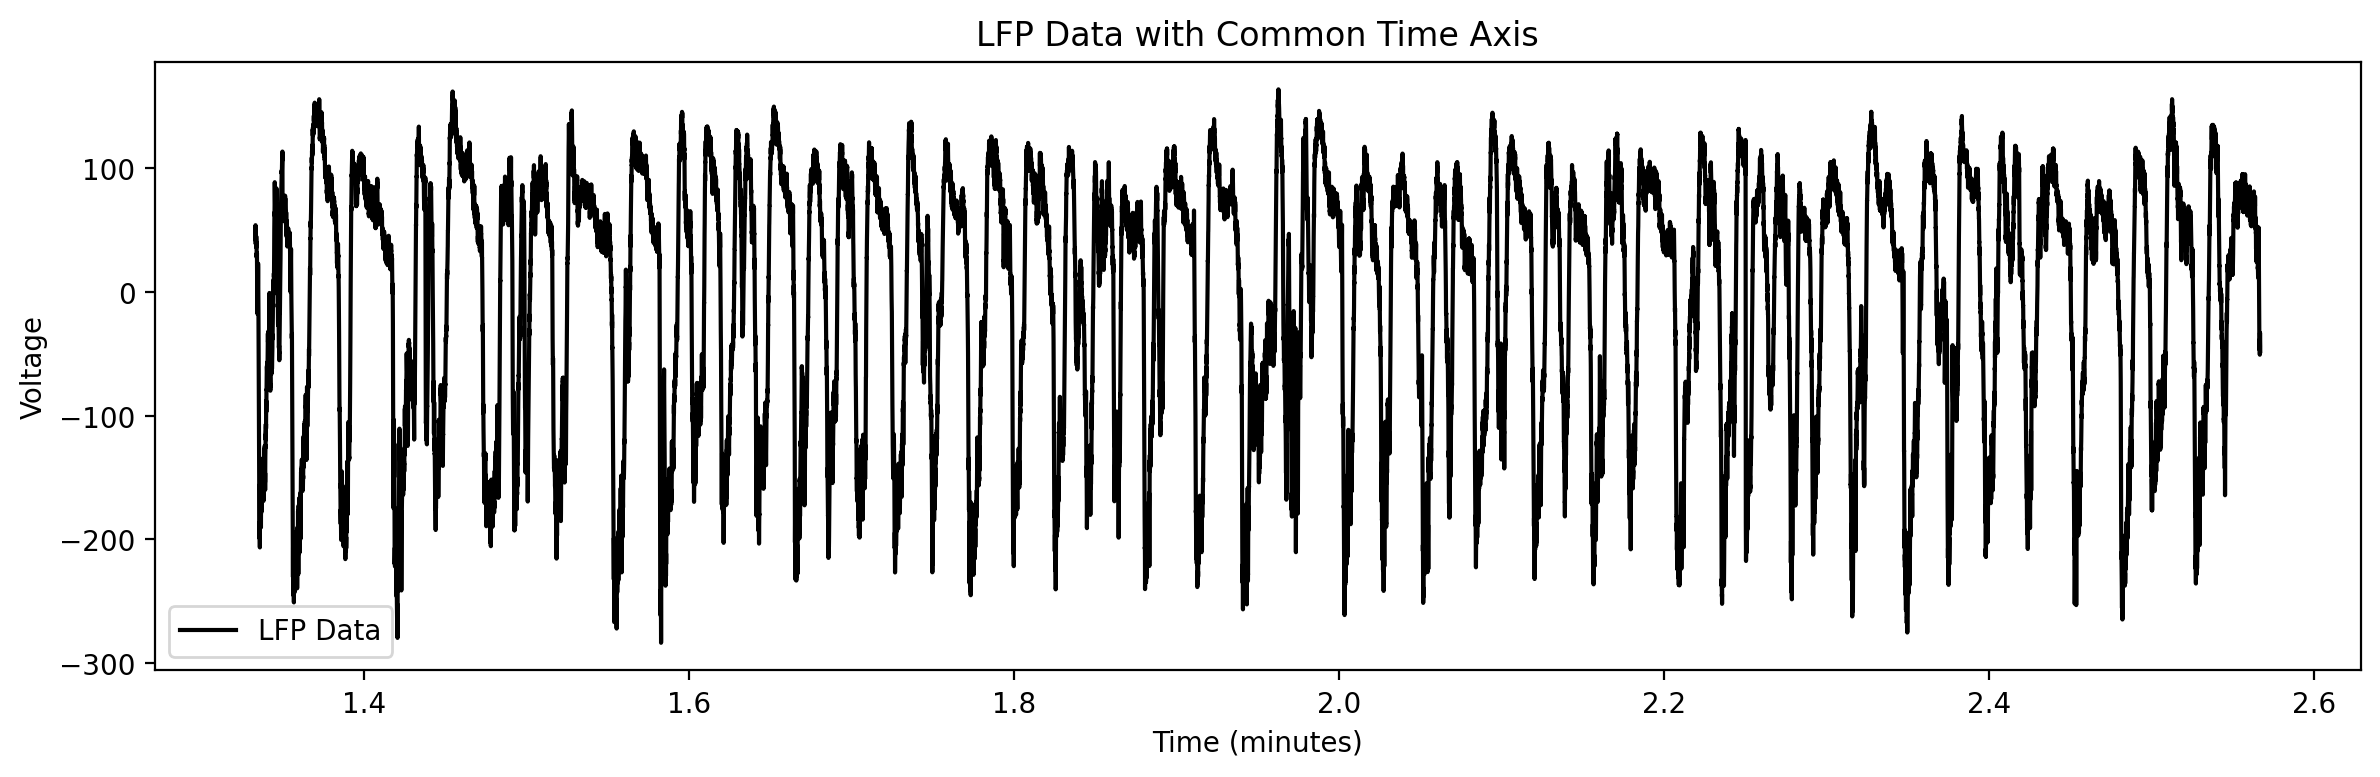

In [6]:
_ =  plot_patch_lfp_aligned(
    patch_times, patch_filt, lfp_times, lfp_filt,
    t_start_ms=80000, t_end_ms=154000
)


## STEP 1: ANALYZE LFP DATA

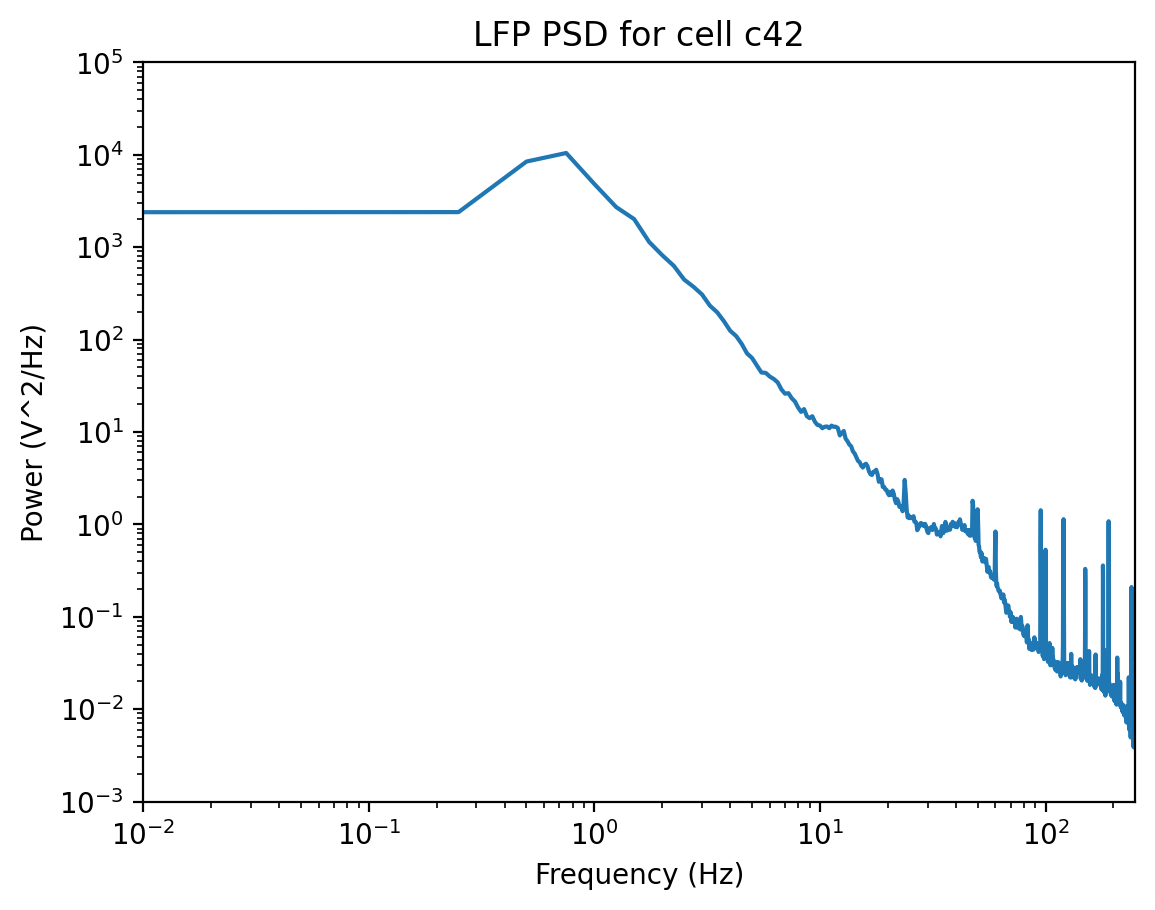

In [7]:

# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


### There seem to be some gamma oscillations 

#### Use specpram to find gamma peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


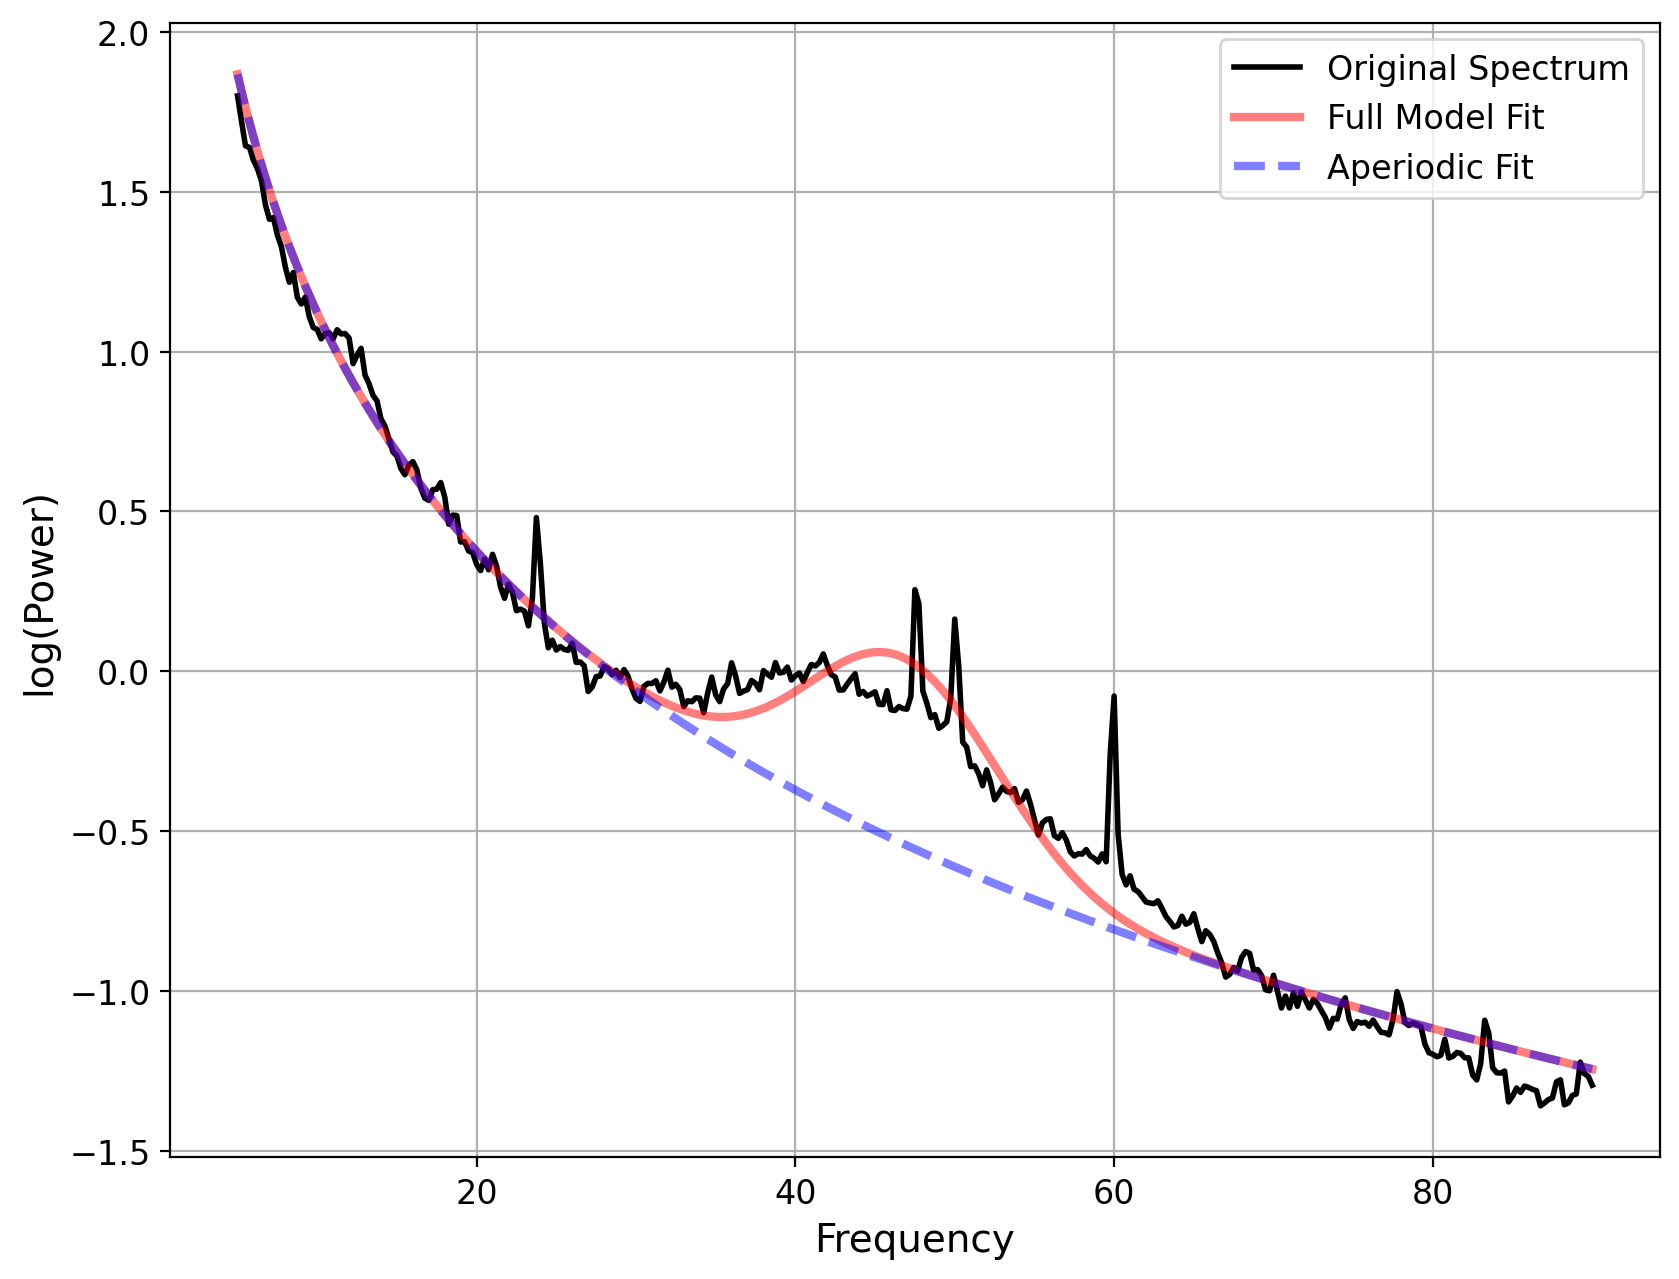

In [8]:
fm = SpectralModel(max_n_peaks=1, verbose=False)
fm.fit(fxx, pxx, freq_range=(5,90))
fm.plot()

# A) Long window specparam classification for kilosort

In [9]:

# SHARED PARAMETERS
lfp_signal = lfp_filt
fs = lfp_fs

# Windowing parameters
window_len_sec = 2
step_size_sec = 1

# Specparam fitting options
fooof_params = {"max_n_peaks": 4, "peak_width_limits": (4, 8), "verbose": False}


In [10]:
# Define a bands object to organize peak parameters
bands = Bands({'gamma' : [30, 90]})

In [11]:
# ---- Compute Welch-based model ----
model_welch, freqs_welch, win_times_welch = compute_lfp_windows(
    lfp_signal=lfp_signal,
    fs=fs,
    method="welch",
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params=fooof_params,
    welch_params={"window": "hann", "nperseg": int(fs)}
)



                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 809                                  
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 1.00 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

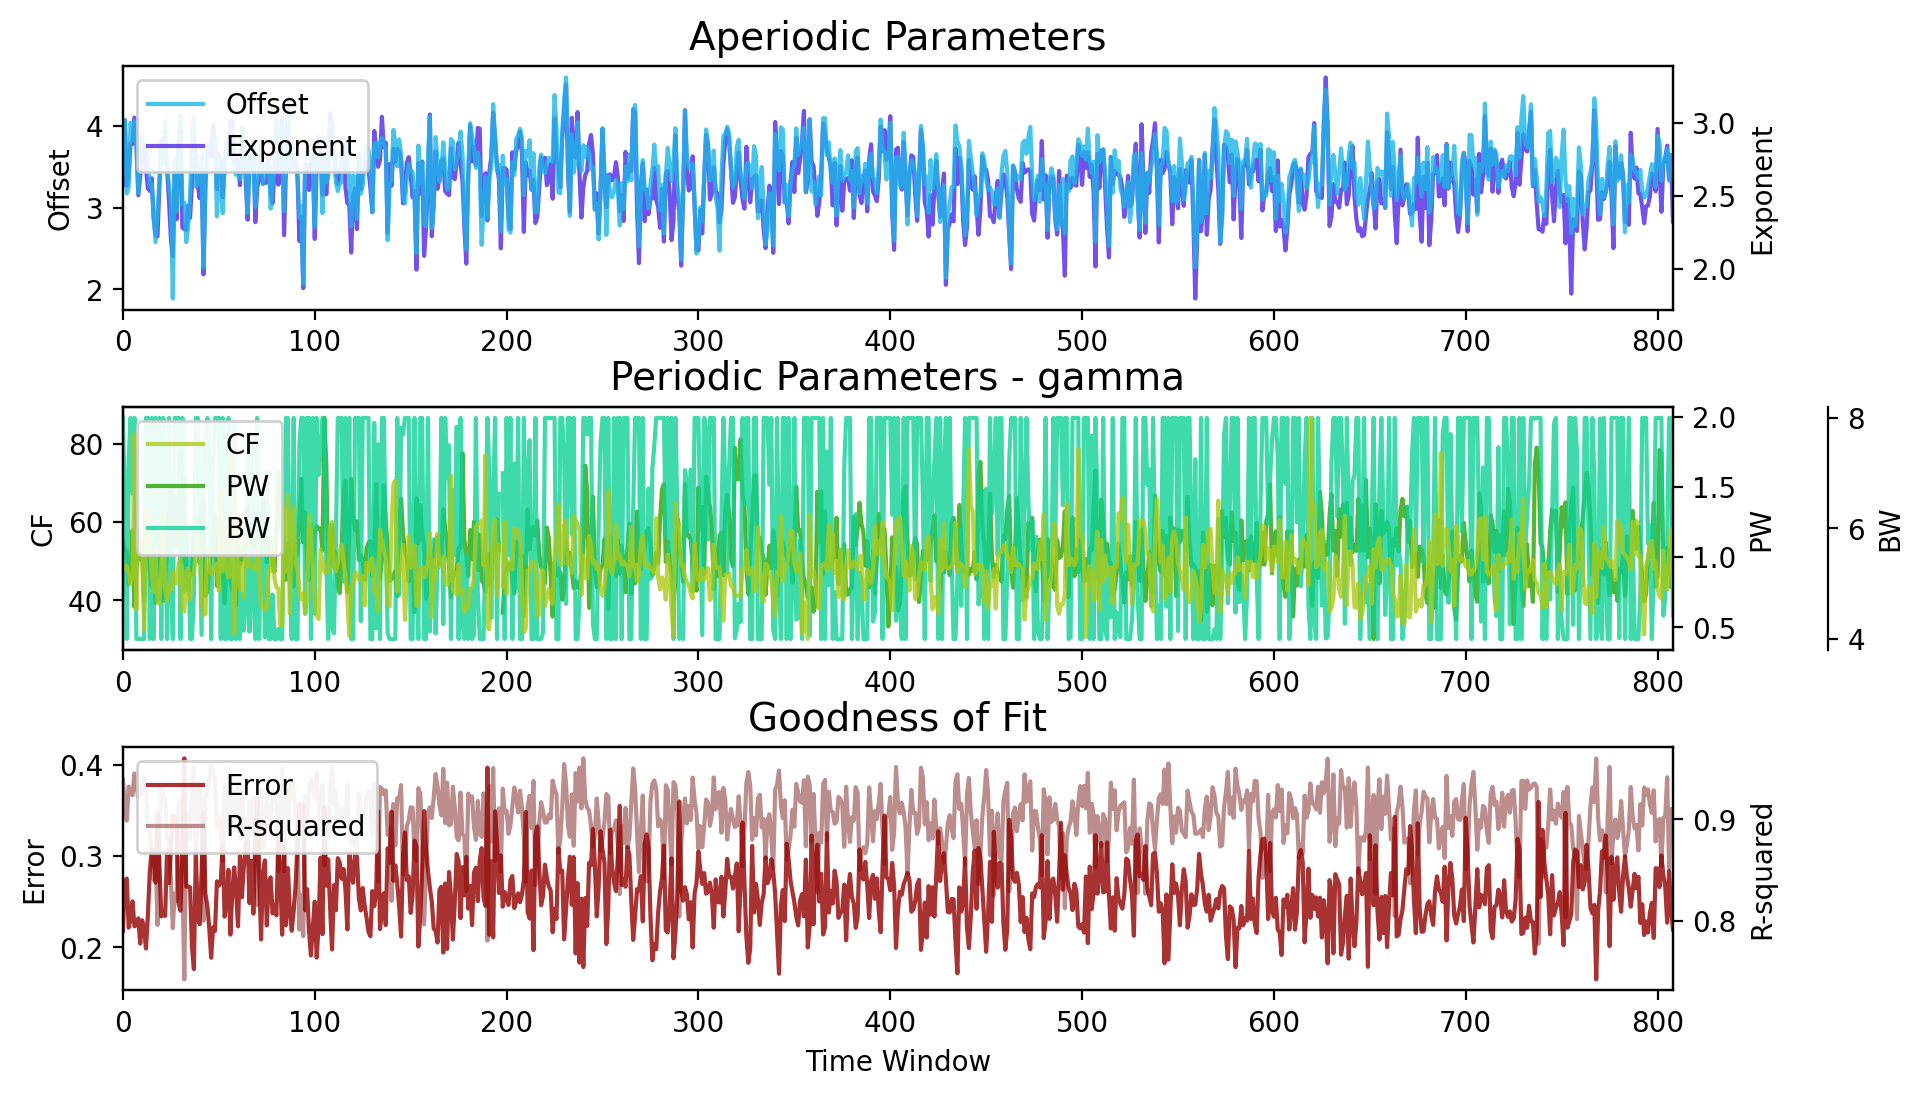

In [12]:
model_welch.report(peak_org=bands)

In [13]:
# Get summary df
summary_df_welch = model_welch.to_df(peak_org=bands)

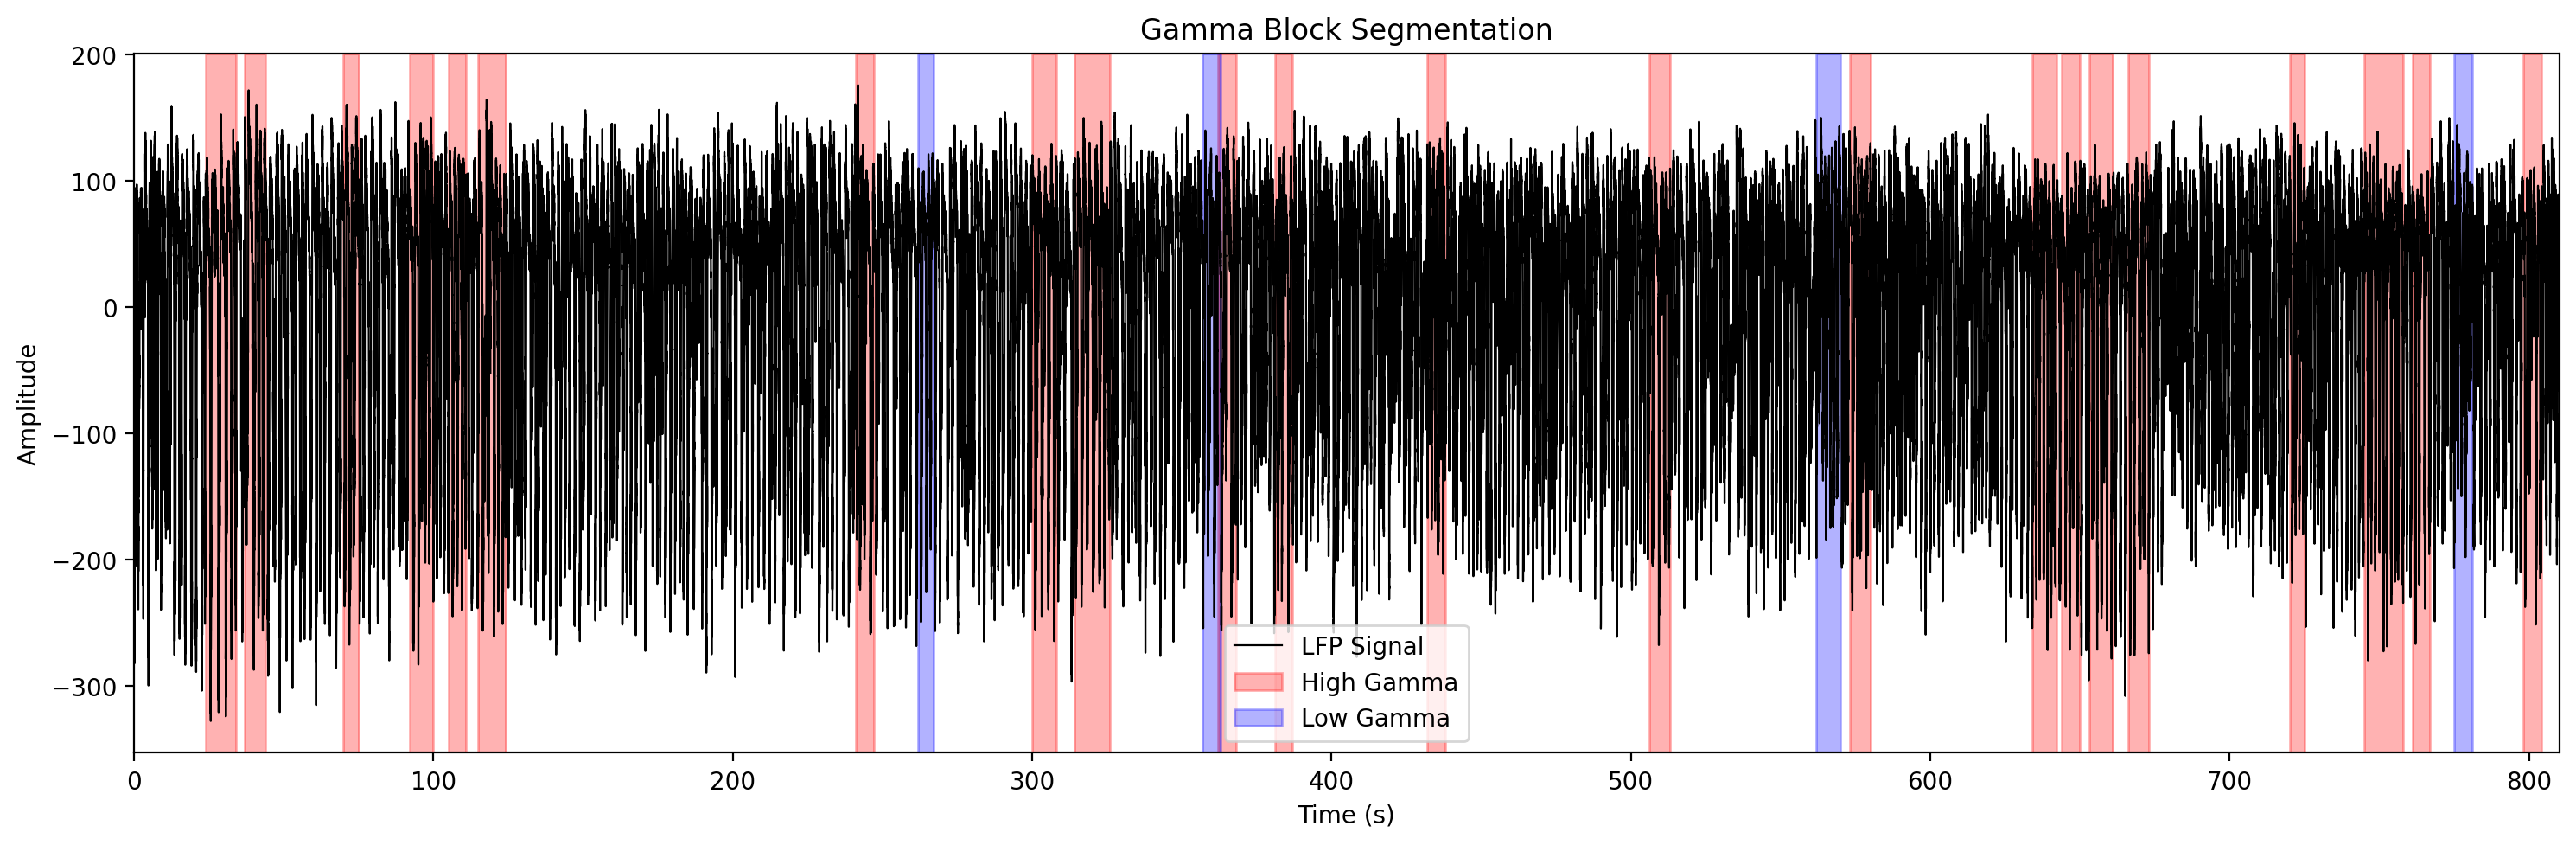

High gamma blocks: 22 | Total duration: 162.00 s
Low gamma blocks:  4 | Total duration: 25.00 s


In [14]:
# Segment windows and blocks
high_windows_welch, low_windows_welch, high_blocks_welch, low_blocks_welch = segment_gamma_epochs(
    summary_df_welch,
    win_times_welch,
    lfp_signal,
    fs,
    window_len_sec=window_len_sec,
    gamma_band_name="gamma",
    visualize=True
)


### Visualize specparam results for low vs high gamma windows 

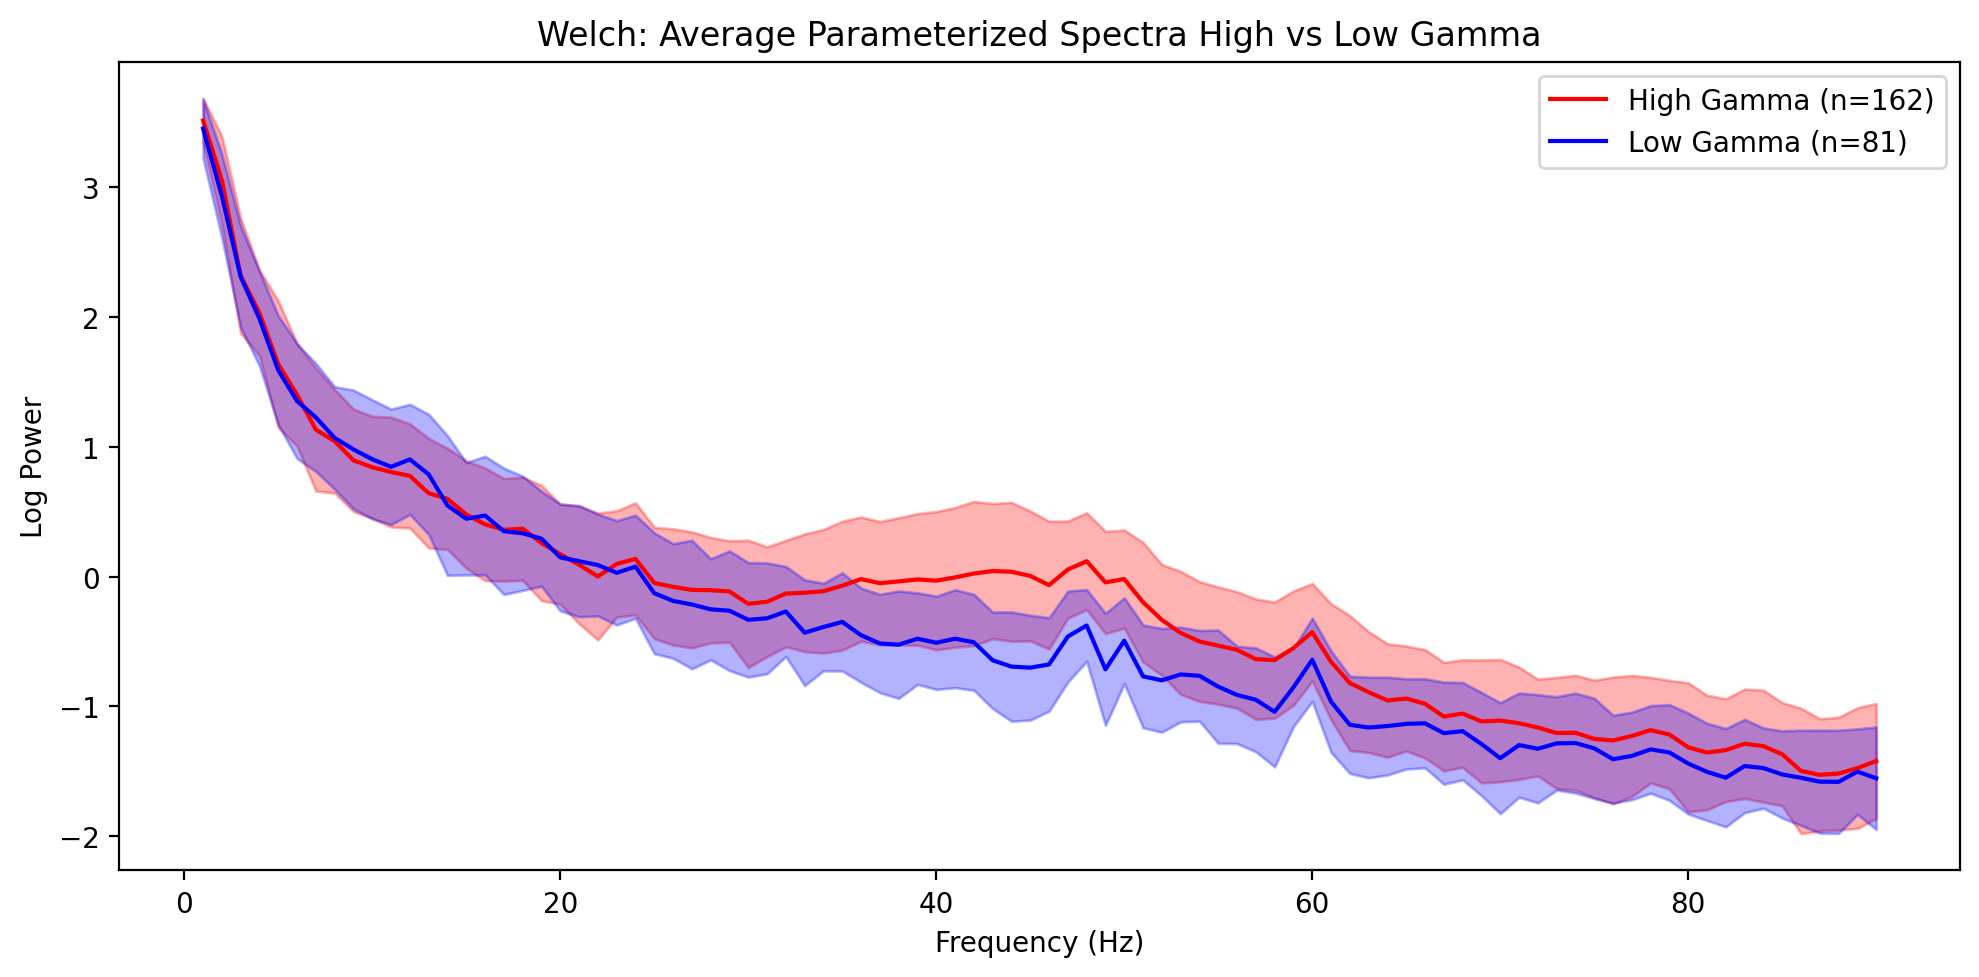

In [15]:
plot_param_spectra_high_low(
    model_welch,
    high_windows_welch,     
    low_windows_welch,       
    window_times=win_times_welch,
    title="Welch: Average Parameterized Spectra High vs Low Gamma"
)


### Replicate with multitapers

In [16]:
# Use multitaper method instead of Welch
model_mt, freqs_mt, win_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method='multitaper',  
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params={"max_n_peaks": 4, "verbose": False},
    multitaper_params={"bandwidth": 4}  
)

                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 809                                  
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 1.82 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

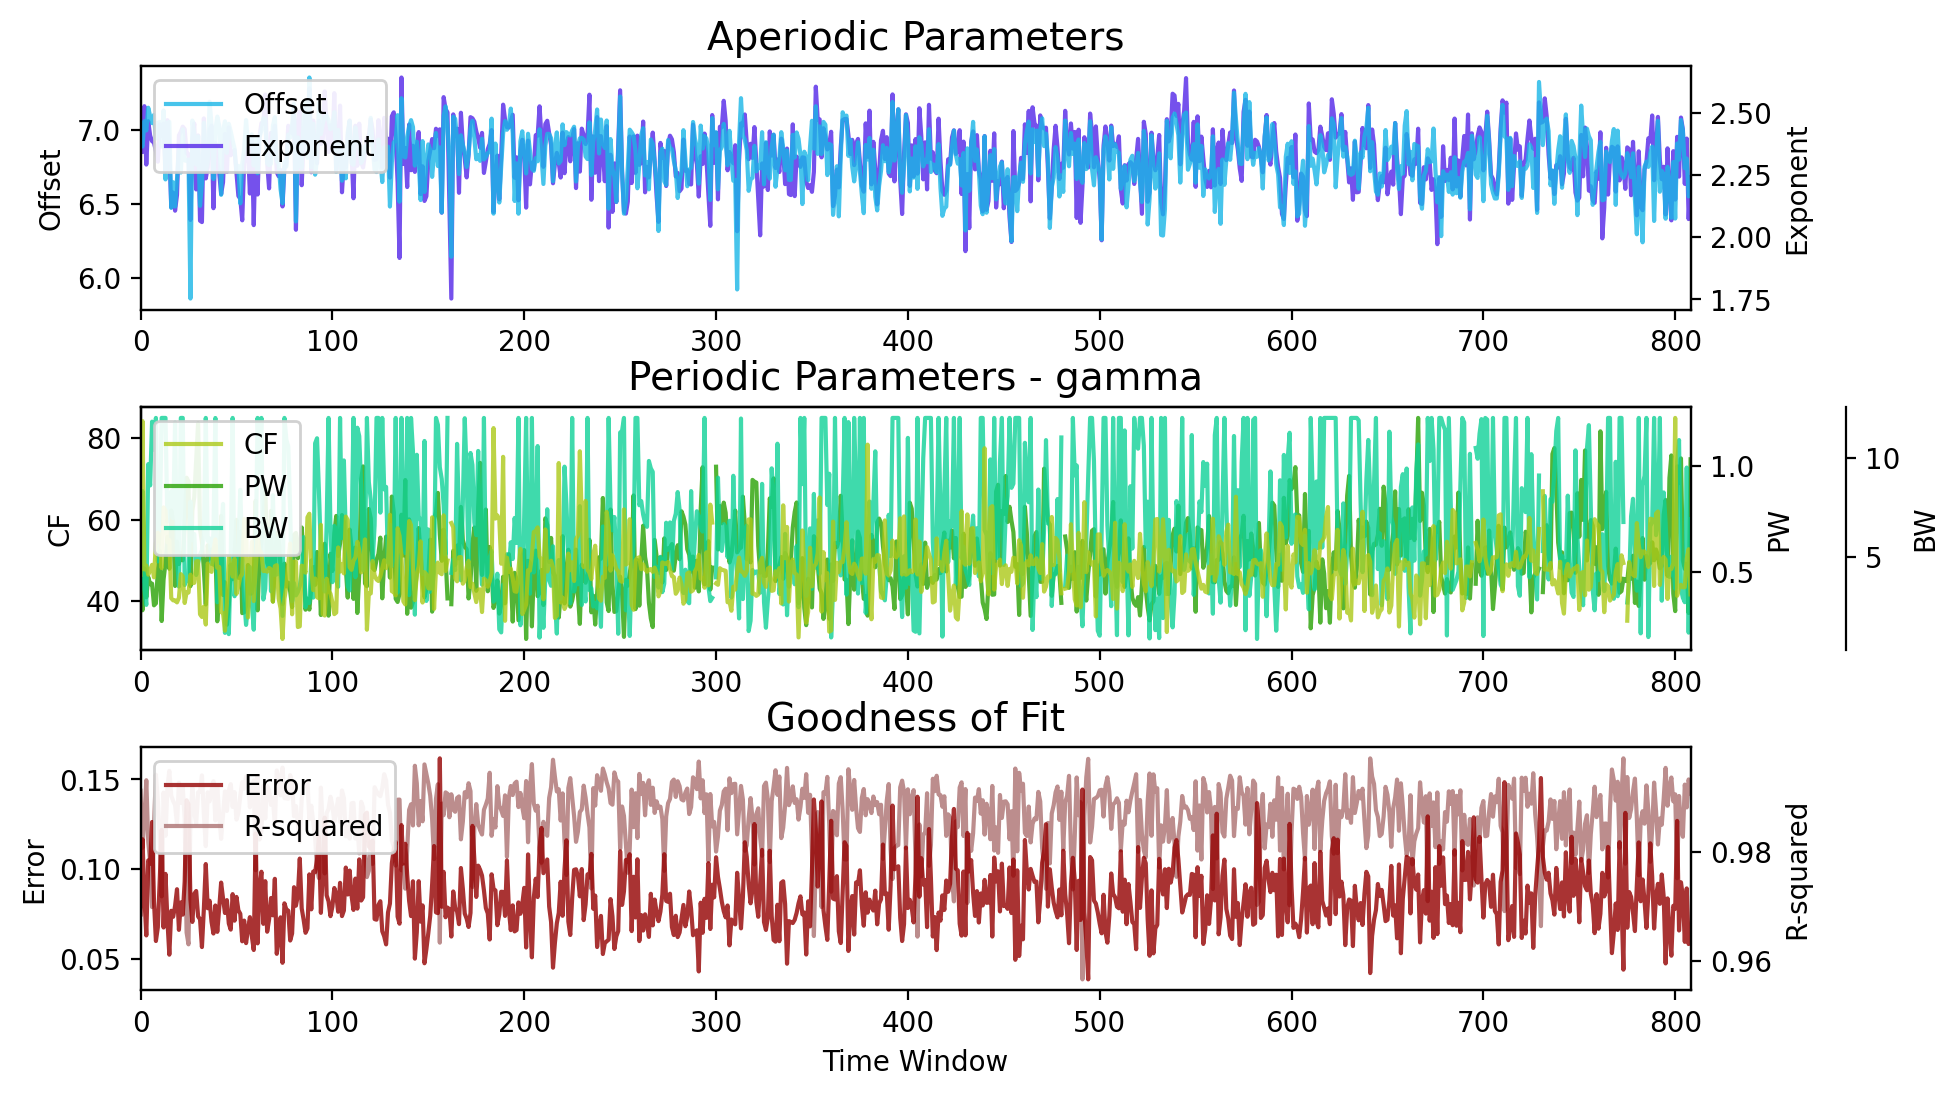

In [17]:
model_mt.report(peak_org=bands)

In [18]:
# Get summary df
summary_df_mt = model_mt.to_df(peak_org=bands)

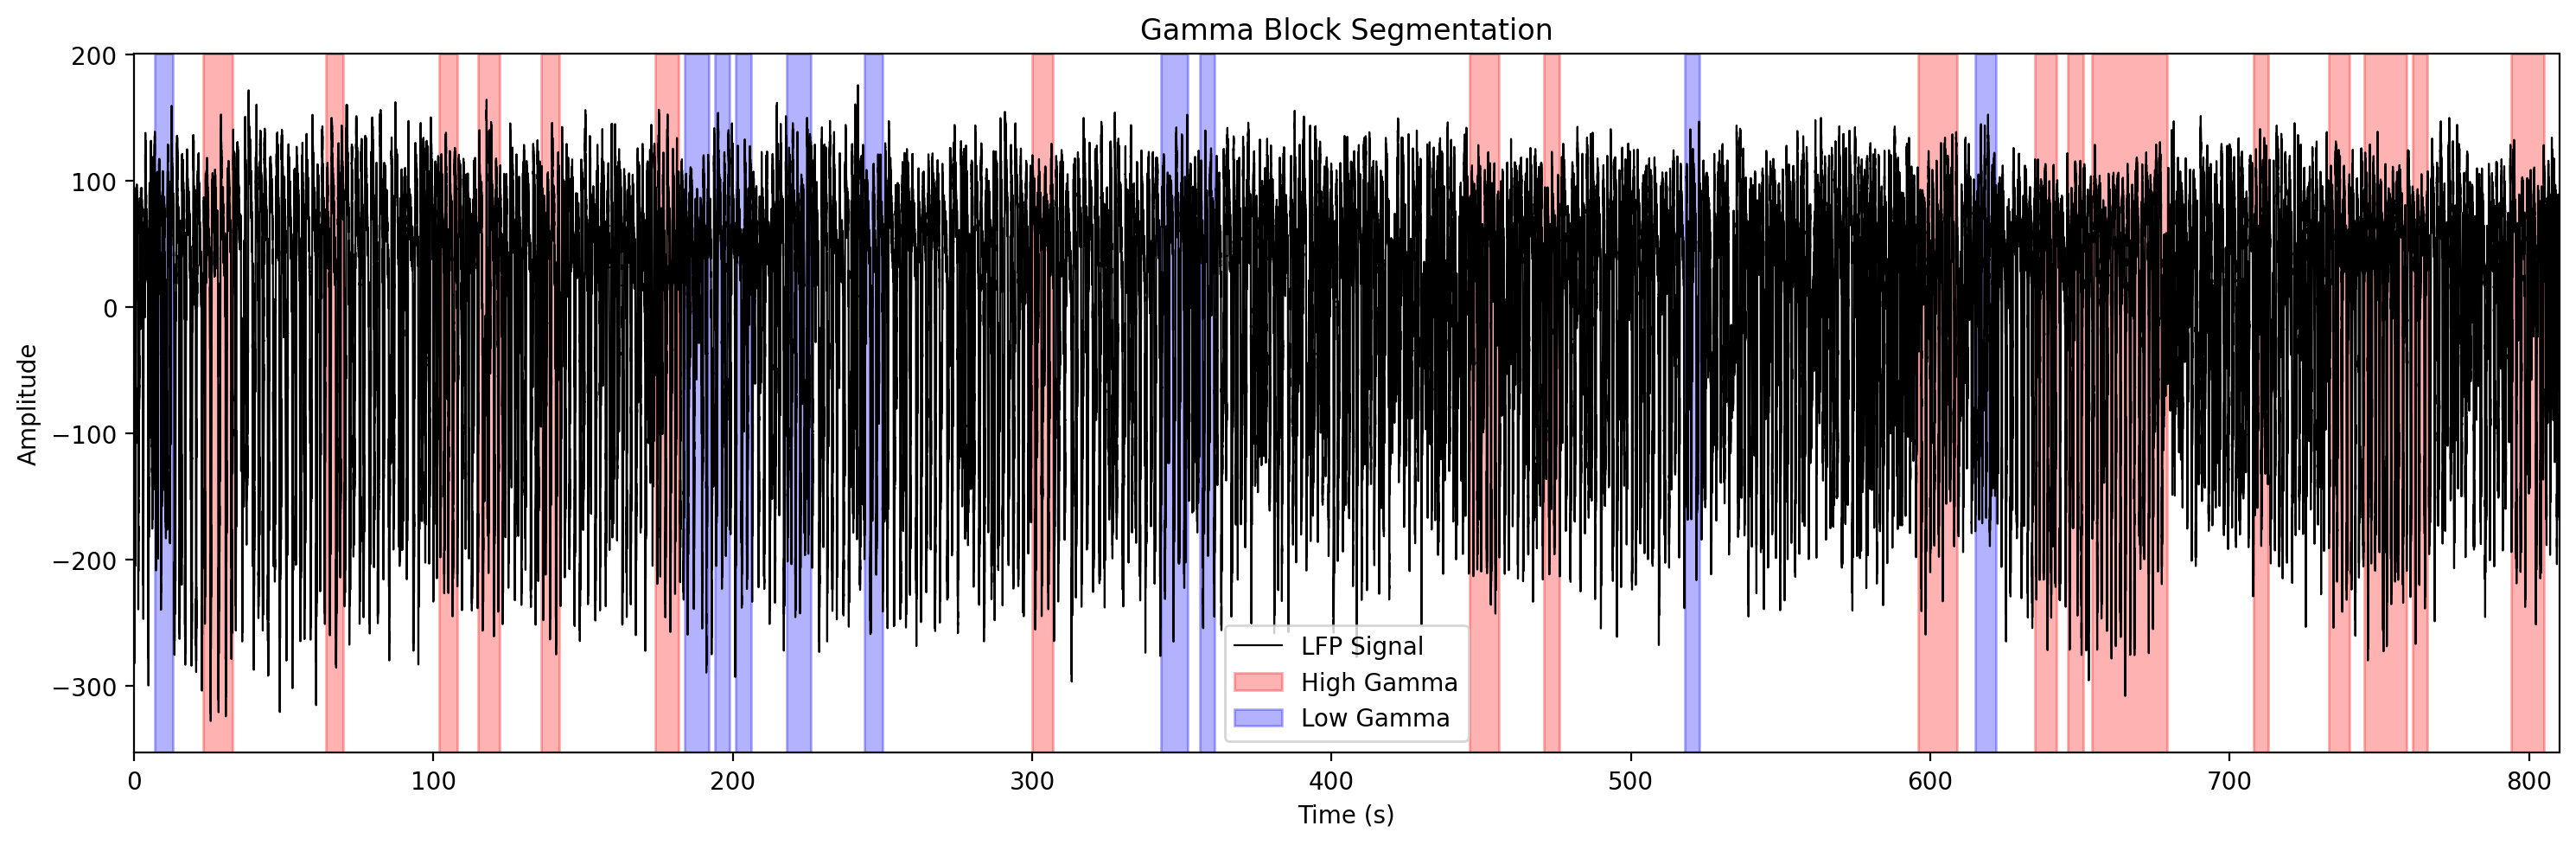

High gamma blocks: 18 | Total duration: 157.00 s
Low gamma blocks:  10 | Total duration: 64.00 s


In [19]:
high_windows_mt, low_windows_mt, high_blocks_mt, low_blocks_mt = segment_gamma_epochs(summary_df_mt, win_times_mt, lfp_filt, lfp_fs)

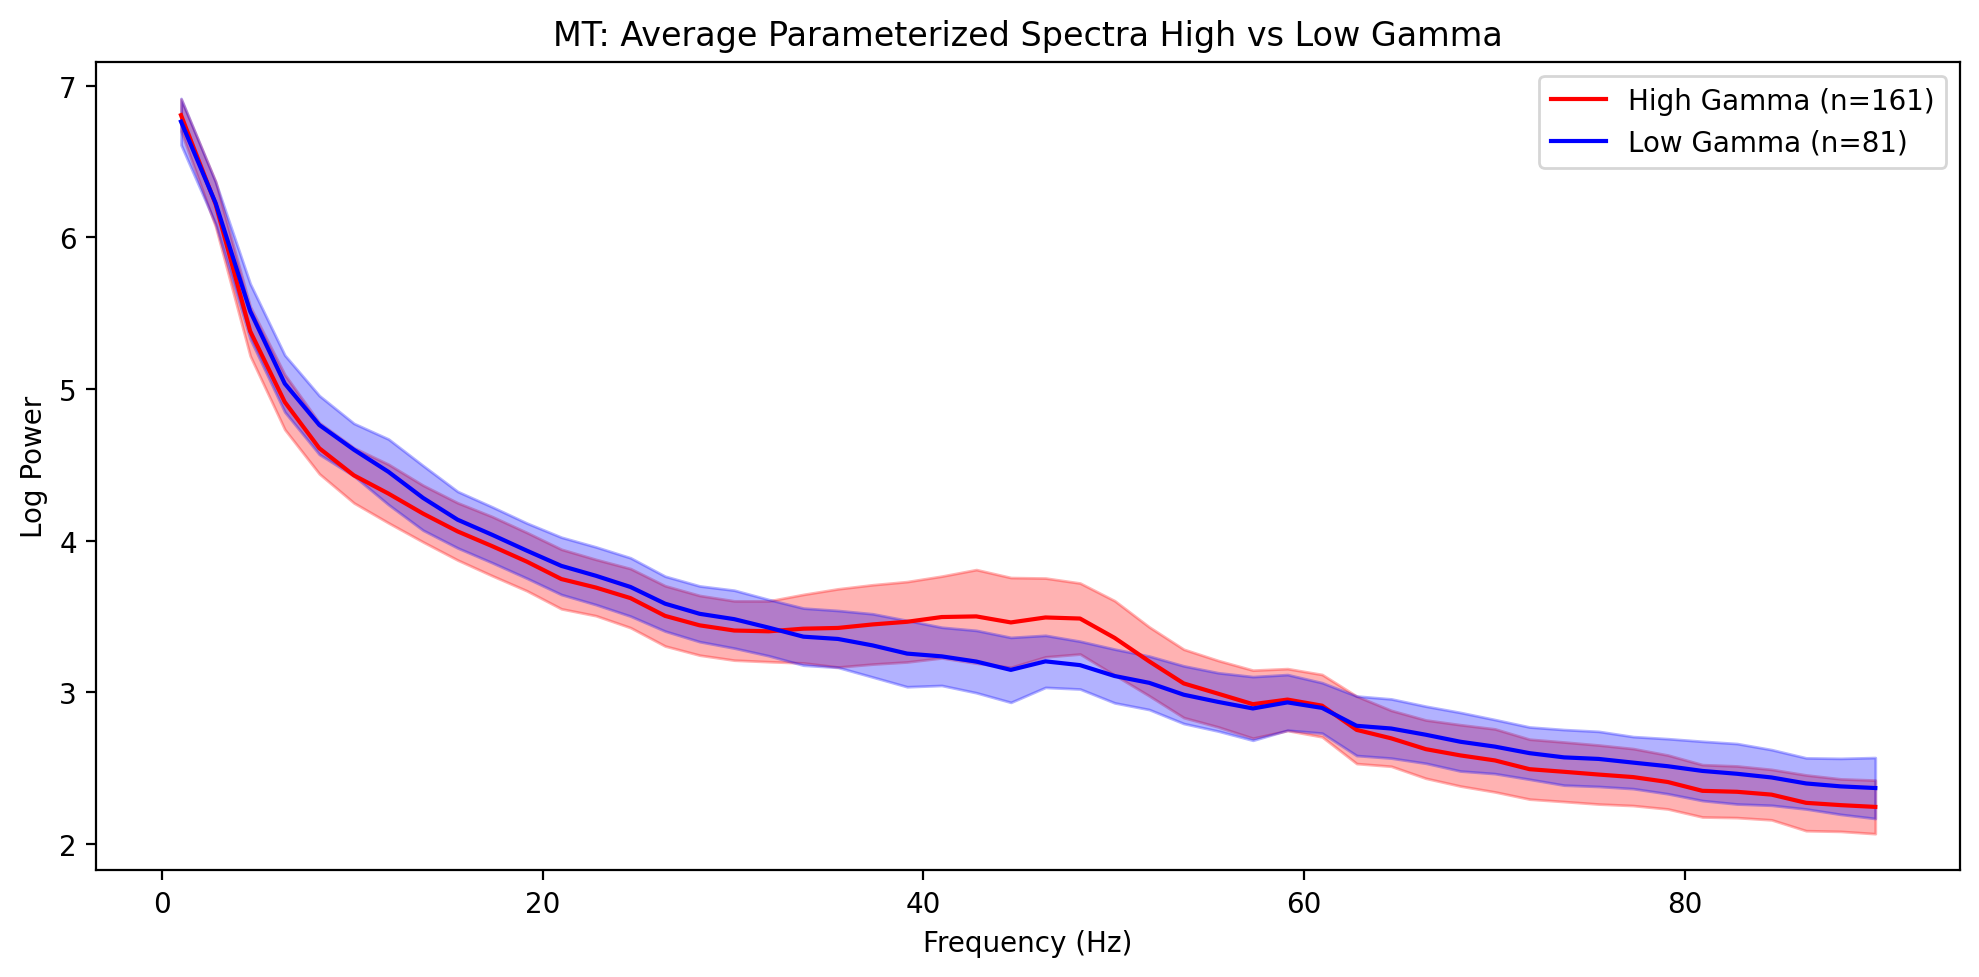

In [20]:
plot_param_spectra_high_low(
    model_mt,
    high_windows_mt,      
    low_windows_mt,       
    window_times=win_times_mt,
    title="MT: Average Parameterized Spectra High vs Low Gamma"
)


### Compare blocks assigned by both methods 

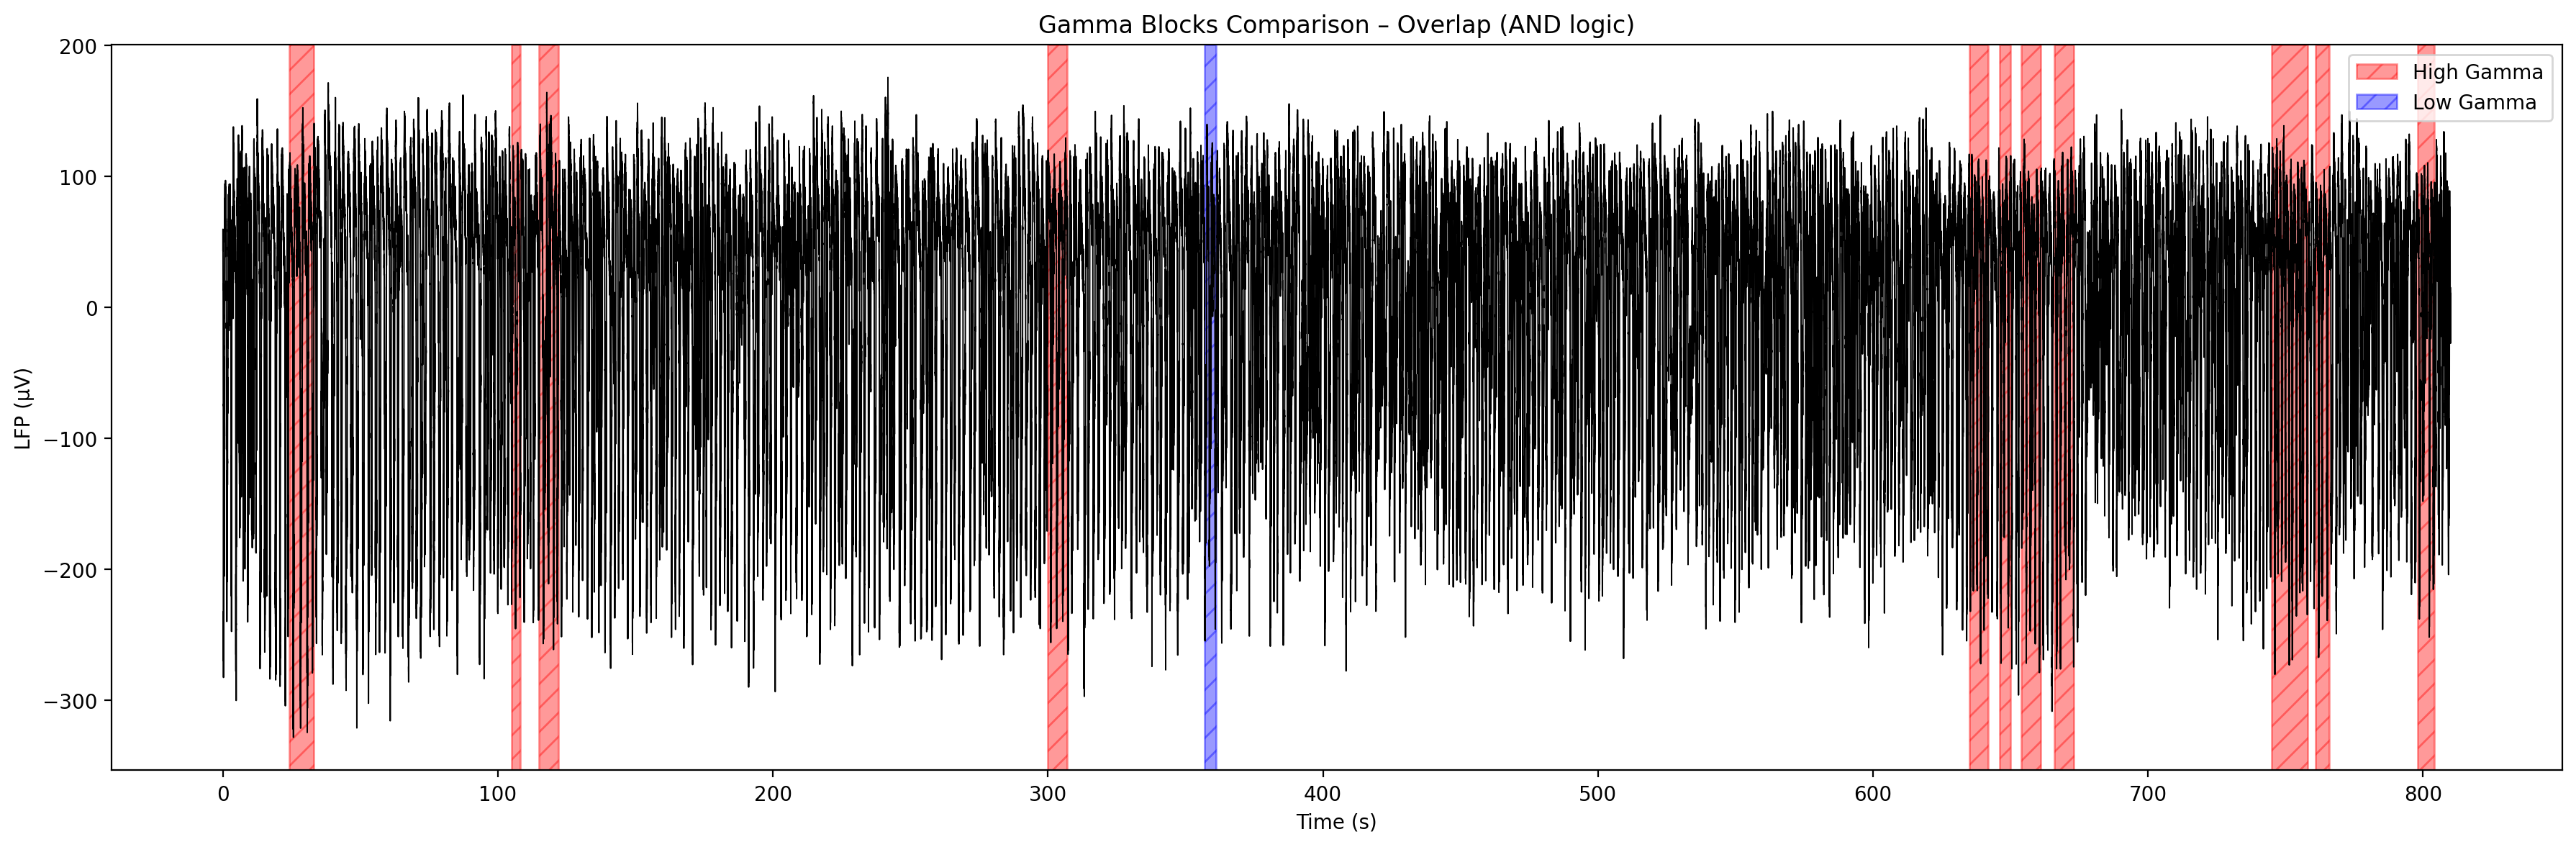

Mode: Overlap (AND logic)
High Gamma: 11 blocks | Total duration: 75.00 s
Low Gamma:  1 blocks | Total duration: 4.00 s


In [21]:
# For overlapping blocks:
plot_gamma_blocks_comparison(lfp_signal, fs, high_blocks_welch, low_blocks_welch,
                              high_blocks_mt, low_blocks_mt, mode="overlap")



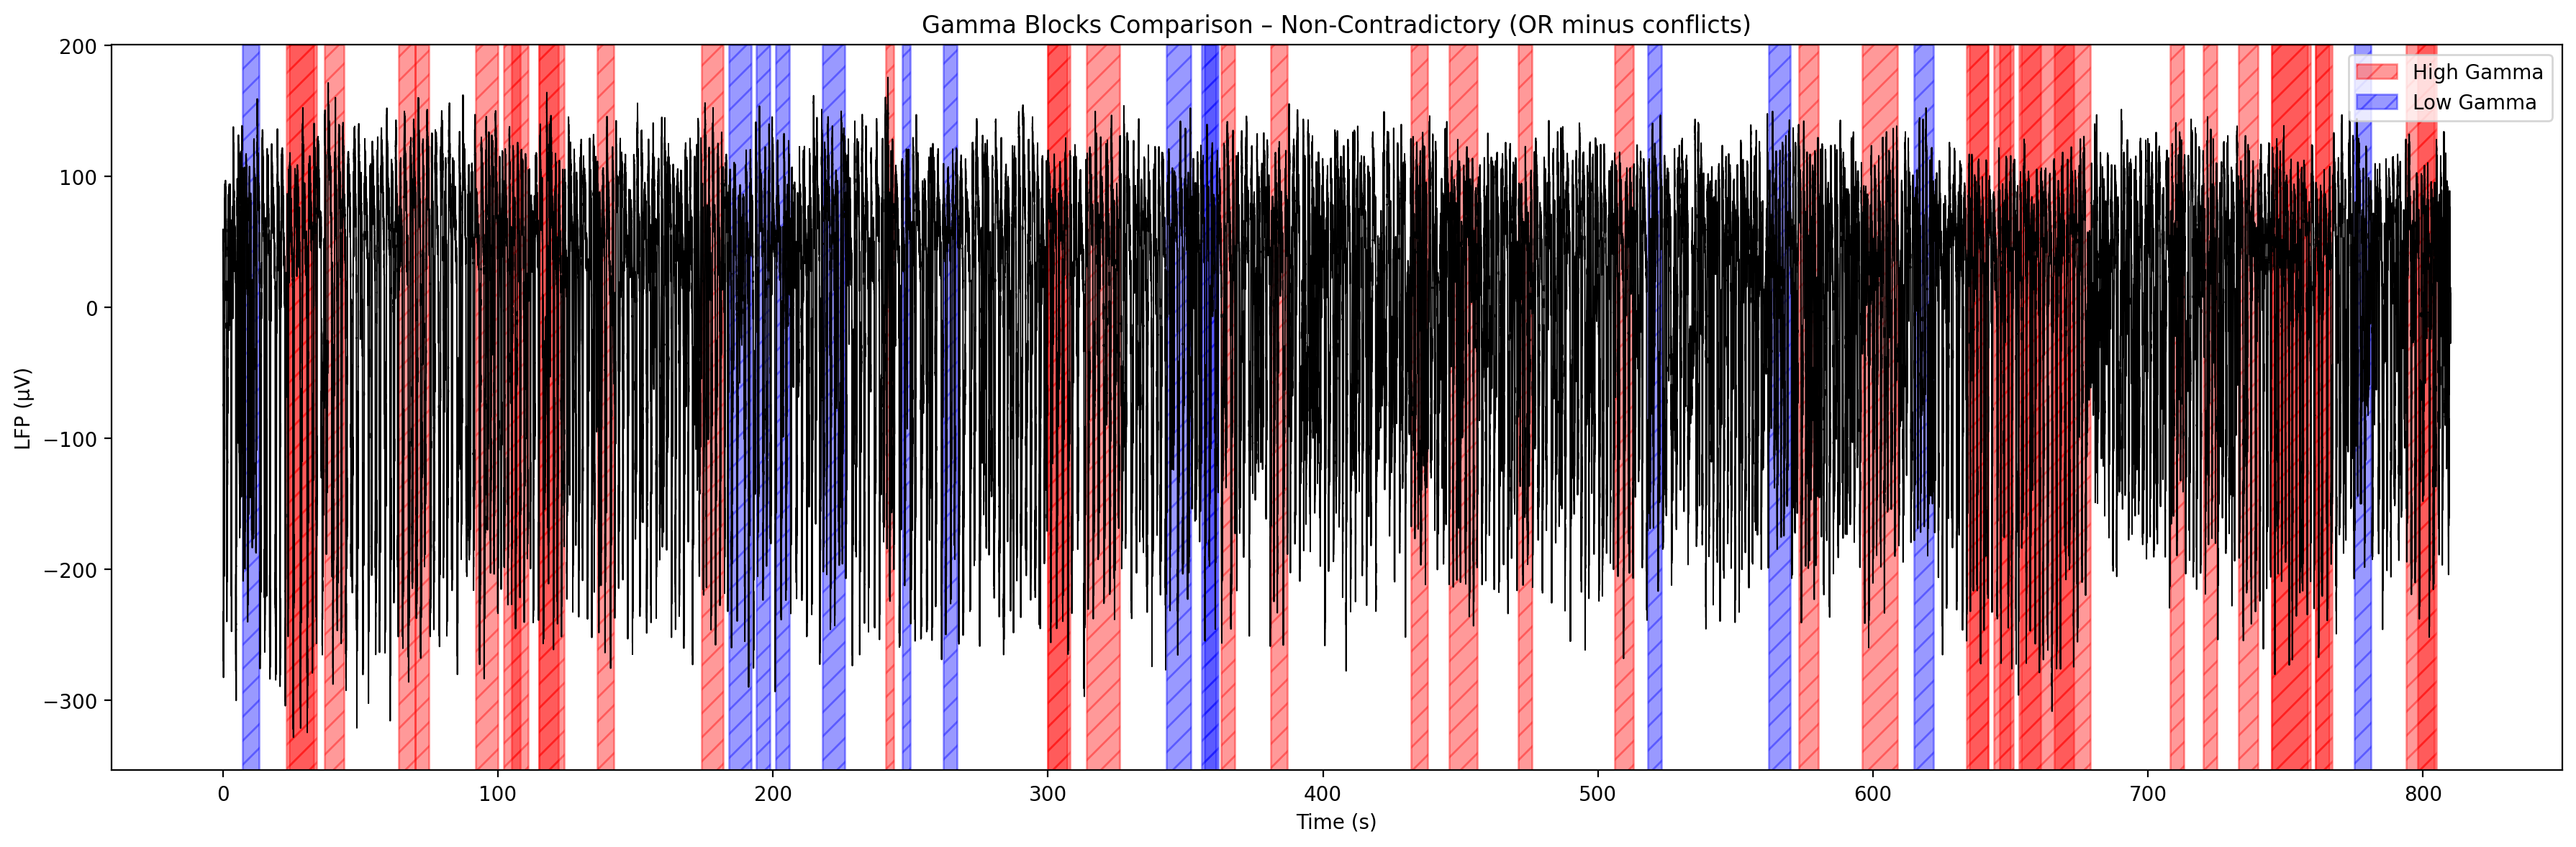

Mode: Non-Contradictory (OR minus conflicts)
High Gamma: 40 blocks | Total duration: 315.00 s
Low Gamma:  14 blocks | Total duration: 85.00 s


In [22]:
# For non-contradictory blocks:
plot_gamma_blocks_comparison(lfp_signal, fs, high_blocks_welch, low_blocks_welch,
                              high_blocks_mt, low_blocks_mt, mode="noncontradictory")

# B) Save high and low blocks as bin files for kilosort  - update

In [ ]:
save_bin_path = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_lfp_bins_c42"


save_lfp_blocks_to_bin(
    lfp_signal=lfp_signal,
    fs=fs,
    overlap_high=overlap_high_segments,
    overlap_low=overlap_low_segments,
    output_dir=save_bin_path
)

# Step 2: Analyze patch spikes from high vs low blocks 

In [25]:
#parameterize all spikes
spk_thresh = 10
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [26]:
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/626 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


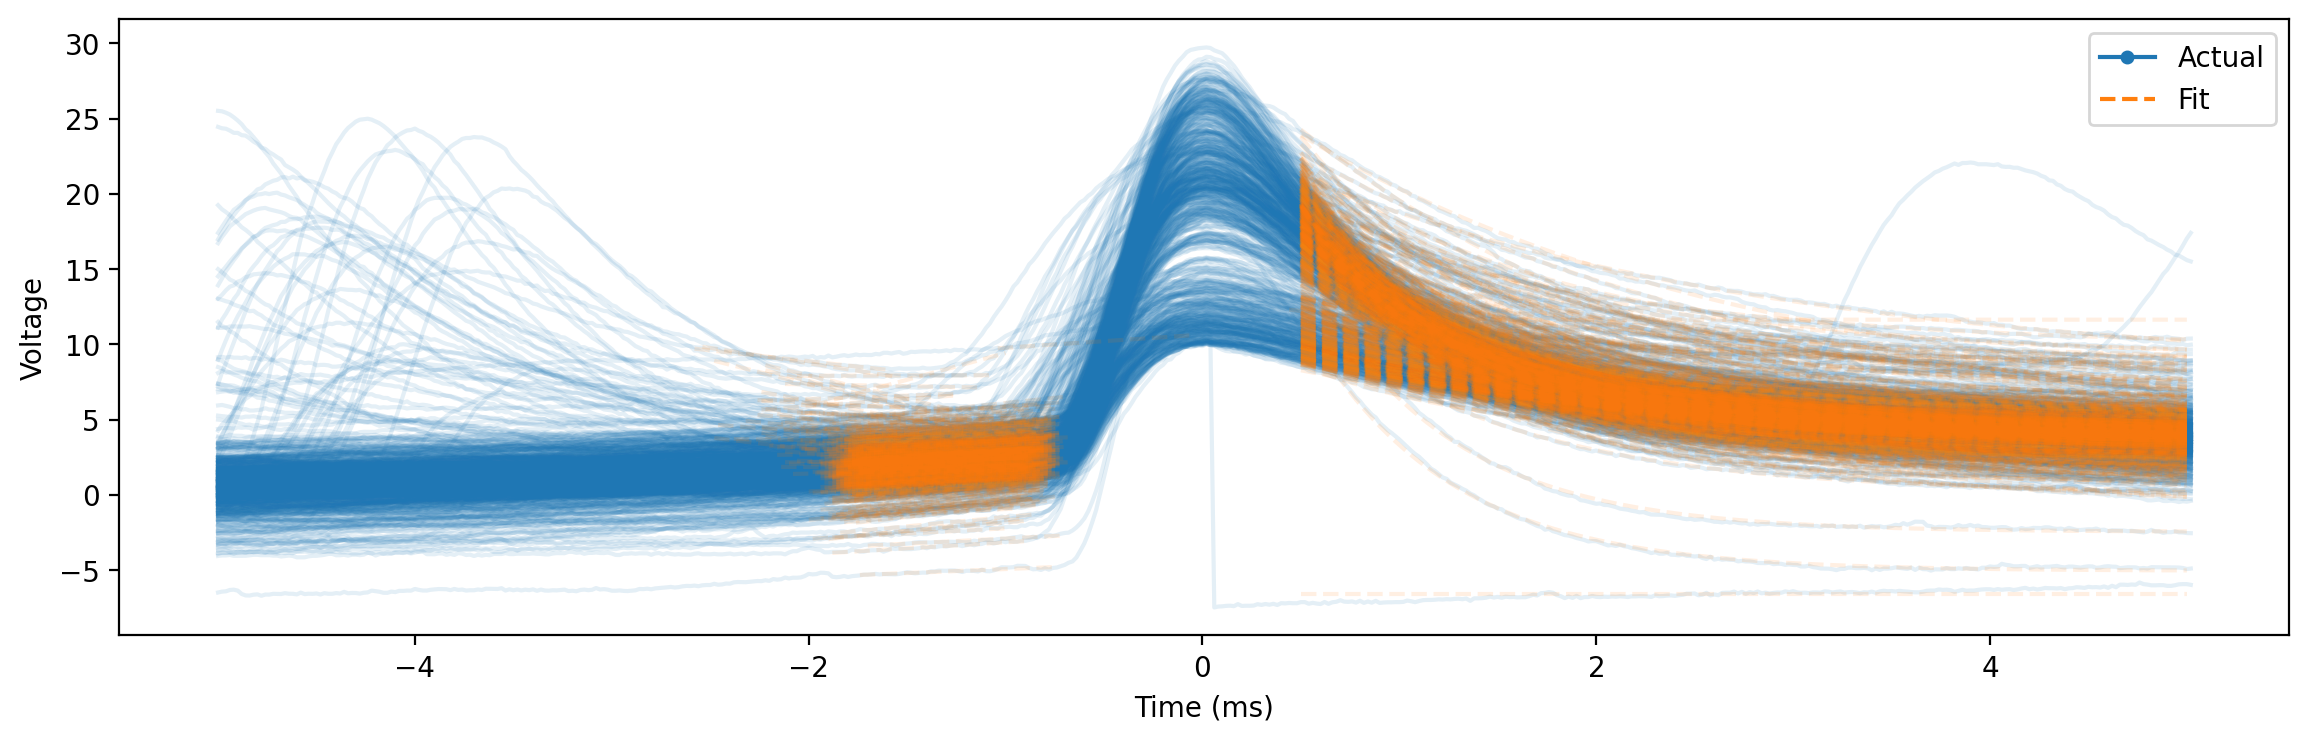

In [27]:
sp.plot()

In [28]:
sp.filter_features()  # Applies default filters in-place

In [29]:
df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [36]:
spike_df_overlap = label_spikes_blocks(spike_df, mode="overlap",
                                       overlap_high=overlap_high_segments,
                                       overlap_low=overlap_low_segments)


NameError: name 'label_spikes_blocks' is not defined

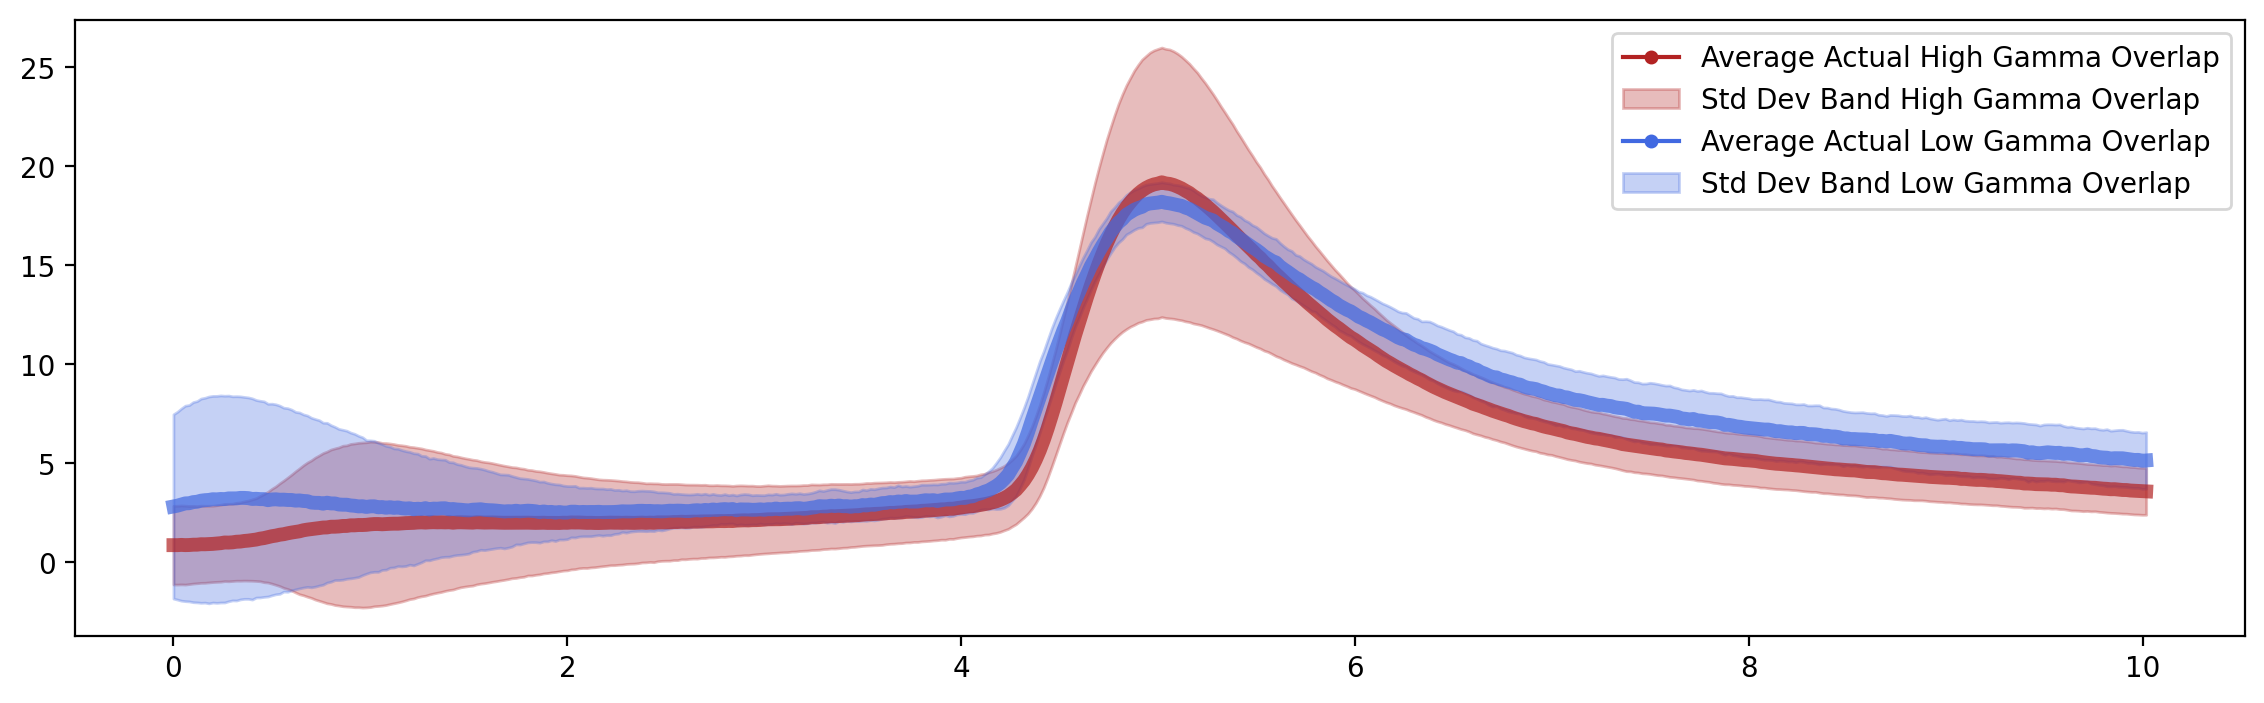

In [31]:
# Extract indices for plotting
# Extract indices for high/low overlap using the spk_id column
high_overlap_inds = spike_df_labeled.loc[
    spike_df_labeled['overlap_block_label'] == 'high_overlap', 'spk_id'
].values

low_overlap_inds = spike_df_labeled.loc[
    spike_df_labeled['overlap_block_label'] == 'low_overlap', 'spk_id'
].values



# Group for plotting
ind_groups = [high_overlap_inds, low_overlap_inds]
group_names = ["High Gamma Overlap", "Low Gamma Overlap"]

# Plot average waveforms with std bands
sp.plot(groups=True,
                 ind_groups=[high_overlap_inds, low_overlap_inds],
                 group_names=["High Gamma Overlap", "Low Gamma Overlap"],
                 plot_average=True,
                 plot_average_std=True)

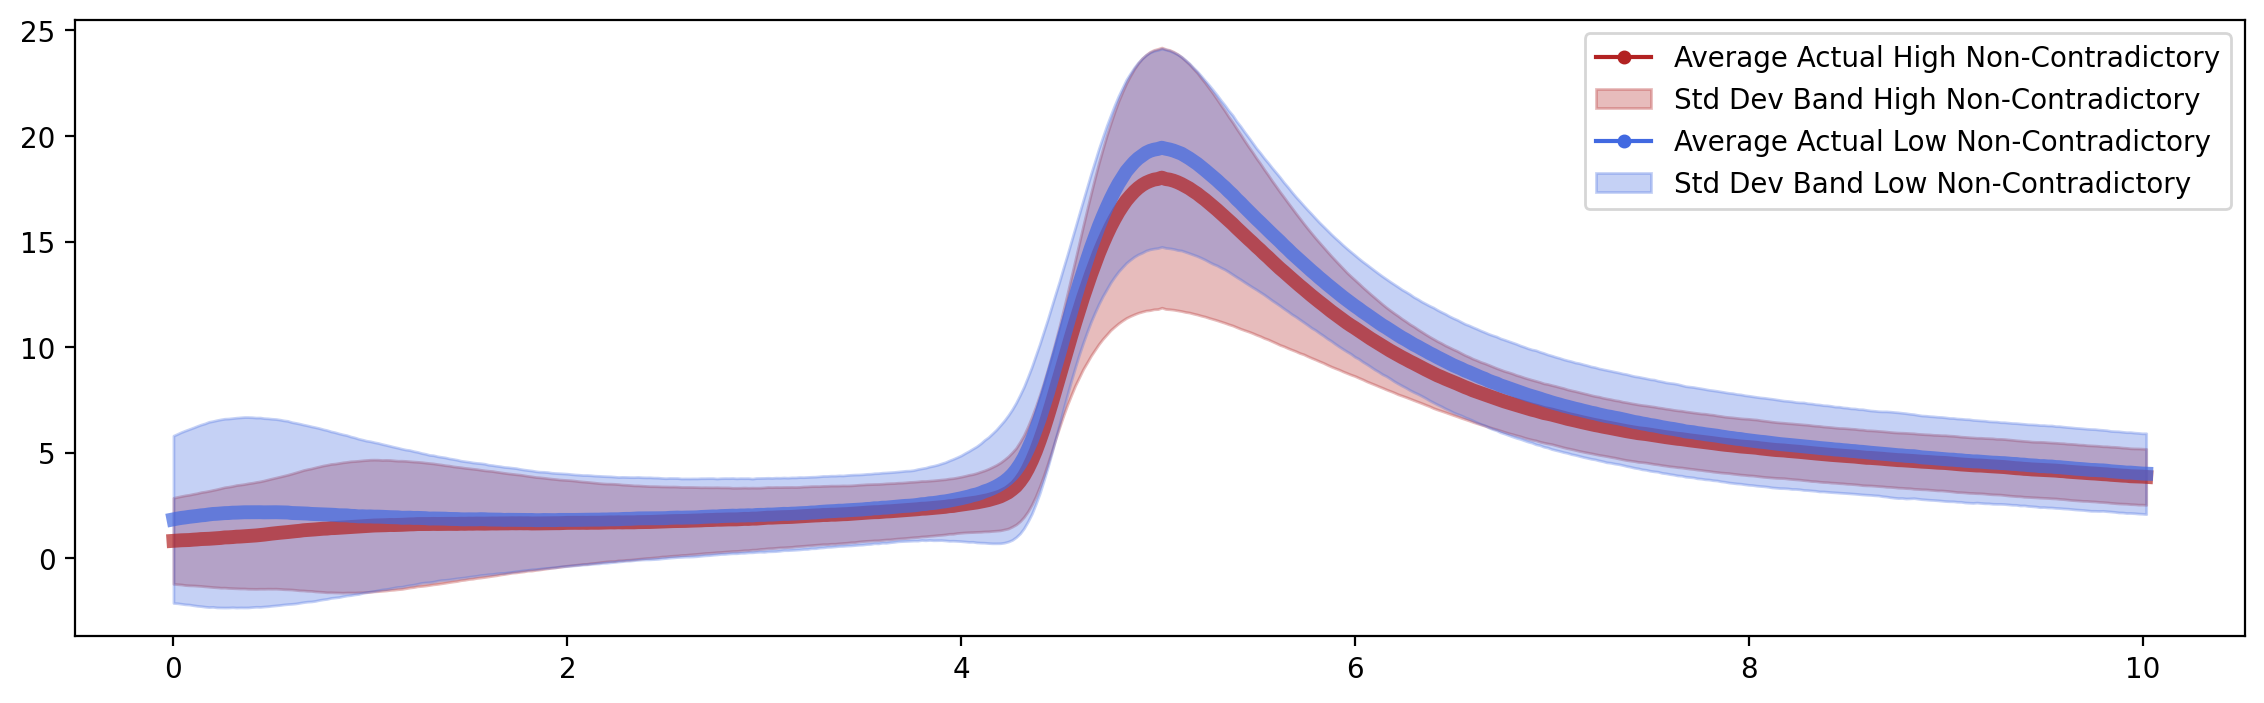

In [32]:
spike_df_noncontr = label_non_contradictory_block_spikes(
    spike_df_labeled,
    high_blocks_welch, low_blocks_welch,
    high_blocks_mt, low_blocks_mt
)


# Use the `spk_id` column, not the DataFrame index
high_nc_inds = spike_df_noncontr.loc[
    spike_df_noncontr['noncontradictory_label'] == 'high_noncontradictory', 'spk_id'
].astype(int).tolist()

low_nc_inds = spike_df_noncontr.loc[
    spike_df_noncontr['noncontradictory_label'] == 'low_noncontradictory', 'spk_id'
].astype(int).tolist()


sp.plot(groups=True, ind_groups=[high_nc_inds, low_nc_inds],
        group_names=["High Non-Contradictory", "Low Non-Contradictory"],
        plot_average=True, plot_average_std=True)


In [ ]:

from scipy.stats import ttest_ind

def compare_spike_params_groups(spike_df, group_col, groups, params):
    """
    Compare spike parameters between two groups using t-tests and violin plots.

    Args:
        spike_df : pd.DataFrame
            DataFrame containing spike parameters and a group label column.
        group_col : str
            Column name in `spike_df` that contains the group labels.
        groups : tuple of str
            Names of the two groups to compare (e.g., ('high_noncontradictory', 'low_noncontradictory')).
        params : list of str
            List of parameter column names to compare.

    Returns:
        results : dict
            Dictionary with parameter -> (t_stat, p_value).
    """
    group1, group2 = groups
    df1 = spike_df[spike_df[group_col] == group1]
    df2 = spike_df[spike_df[group_col] == group2]

    results = {}

    for param in params:
        vals1 = df1[param].dropna()
        vals2 = df2[param].dropna()

        # Run Welch's t-test
        t_stat, p_val = ttest_ind(vals1, vals2, equal_var=False, nan_policy='omit')
        results[param] = (t_stat, p_val)

        # --- Plot ---
        plt.figure(figsize=(5,4))
        sns.violinplot(data=[vals1, vals2], cut=0)
        plt.xticks([0,1], [group1, group2])
        plt.ylabel(param)
        plt.title(f"{param}\n t={t_stat:.2f}, p={p_val:.4f}")  # <-- normal decimal format
        plt.tight_layout()
        plt.show()

    return results


In [ ]:
spike_df_noncontr

In [ ]:
# Define groups and parameters to compare
groups_to_compare = ('high_noncontradictory', 'low_noncontradictory')
params_to_check = ['peak_amp', 'peak_width', 'peak_sharpness', 'ramp_amp', 'inflection_time', 'exp_lambda', 'exp_const', 'log_isi']

# Run comparison
results = compare_spike_params_groups(
    spike_df_noncontr,
    group_col='noncontradictory_label',
    groups=groups_to_compare,
    params=params_to_check
)

# Print results
for param, (t, p) in results.items():
    print(f"{param}: t={t:.3f}, p={p:.3e}")
